In [1]:

# Import required libraries
import numpy as np
import pandas as pd
import pickle
from scipy import stats
from scipy.stats import gumbel_r
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# First, let's load the existing GEV analysis results to understand the data structure
with open('gev_analysis_results.pkl', 'rb') as f:
 gev_data = pickle.load(f)

print("Keys in GEV data:", gev_data.keys())
print("\nExamining structure of loaded data:")
for key in list(gev_data.keys())[:3]: # Show first 3 keys
 print(f"\n{key}:")
 if isinstance(gev_data[key], dict):
 print(f" Type: dict with keys {list(gev_data[key].keys())}")
 else:
 print(f" Type: {type(gev_data[key])}")


Keys in GEV data: dict_keys(['parameters', 'functions', 'statistical_tests'])

Examining structure of loaded data:

parameters:
 Type: dict with keys ['N', 't_min', 't_max', 'delta_t', 'n_t_values', 'n_blocks']

functions:
 Type: dict with keys ['zeta', 'F_k2', 'F_k3']

statistical_tests:
 Type: dict with keys ['pairwise_differences', 'all_significant']


In [2]:

# The existing pickle only has 3 functions (zeta, F_k2, F_k3)
# We need to generate the full dataset from r40 with 14 functions
# Let me check what's in the functions data

print("Function data structure:")
for func_name in gev_data['functions'].keys():
 print(f"\n{func_name}:")
 func_data = gev_data['functions'][func_name]
 print(f" Keys: {func_data.keys()}")
 if 'gev_params' in func_data:
 print(f" GEV params: {func_data['gev_params']}")
 if 'block_maxima' in func_data:
 print(f" Block maxima shape: {func_data['block_maxima'].shape}")


Function data structure:

zeta:
 Keys: dict_keys(['name', 'description', 'xi', 'ci_lower', 'ci_upper', 'loc', 'scale', 'maxima'])

F_k2:
 Keys: dict_keys(['name', 'description', 'xi', 'ci_lower', 'ci_upper', 'loc', 'scale', 'maxima'])

F_k3:
 Keys: dict_keys(['name', 'description', 'xi', 'ci_lower', 'ci_upper', 'loc', 'scale', 'maxima'])


In [3]:

# The existing artifact only has 3 functions, but we need 14 functions from r40
# We need to generate the full dataset: ζ(s), F_k1, F_k2, F_k3, and 10 random multiplicative functions
# This requires:
# 1. Computing Dirichlet partial sums D_F(t;N) for all 14 functions
# 2. Computing S_k covariance matrices for each
# 3. Computing block maxima and fitting Gumbel distributions

# Let's start by defining the core functions with Kahan summation and numba JIT compilation
from numba import jit

# First, let's implement the Kahan compensated summation for Dirichlet sums
@jit(nopython=True)
def kahan_sum_complex(values):
 """Kahan compensated summation for complex arrays"""
 s = 0.0 + 0.0j
 c = 0.0 + 0.0j
 for val in values:
 y = val - c
 t = s + y
 c = (t - s) - y
 s = t
 return s

# Pre-compute omega(n) values (number of distinct prime factors)
def compute_omega(N):
 """Compute ω(n) for n=1 to N using sieve"""
 omega = np.zeros(N+1, dtype=np.int32)
 for p in range(2, N+1):
 if omega[p] == 0: # p is prime
 for multiple in range(p, N+1, p):
 omega[multiple] += 1
 return omega

# Pre-compute Omega(n) values (number of prime factors with multiplicity)
def compute_big_omega(N):
 """Compute Ω(n) for n=1 to N"""
 big_omega = np.zeros(N+1, dtype=np.int32)
 for p in range(2, N+1):
 if big_omega[p] == 0: # p is prime
 power = p
 while power <= N:
 for multiple in range(power, N+1, power):
 big_omega[multiple] += 1
 power *= p
 return big_omega

print("Computing arithmetic functions for N=10^5...")
N = 100000
omega = compute_omega(N)
big_omega = compute_big_omega(N)
print(f"omega computed: min={omega[2:].min()}, max={omega[2:].max()}")
print(f"big_omega computed: min={big_omega[2:].min()}, max={big_omega[2:].max()}")


Computing arithmetic functions for N=10^5...


omega computed: min=1, max=6
big_omega computed: min=1, max=16


In [4]:

# Now implement the Dirichlet sum computation with Kahan summation
@jit(nopython=True)
def compute_dirichlet_sum_kahan(a_n, t, N):
 """
 Compute D_F(t;N) = Σ_{n≤N} a_n / n^(1/2+it) using Kahan summation
 
 Args:
 a_n: coefficient array (length N+1, index 0 unused)
 t: ordinate value
 N: truncation depth
 
 Returns:
 complex: the Dirichlet sum
 """
 terms = np.empty(N, dtype=np.complex128)
 
 for n in range(1, N+1):
 # n^(1/2+it) = n^(1/2) * n^(it) = sqrt(n) * exp(it*log(n))
 sqrt_n = np.sqrt(float(n))
 log_n = np.log(float(n))
 phase = t * log_n
 
 # exp(i*phase) = cos(phase) + i*sin(phase)
 exp_it_log_n = np.cos(phase) + 1j * np.sin(phase)
 
 # a_n / n^(1/2+it)
 denominator = sqrt_n * exp_it_log_n
 terms[n-1] = a_n[n] / denominator
 
 return kahan_sum_complex(terms)

print("Dirichlet sum function defined with Kahan summation")


Dirichlet sum function defined with Kahan summation


In [5]:

# Define coefficient functions for different L-functions
def get_zeta_coefficients(N):
 """Riemann zeta: a_n = 1 for all n"""
 a_n = np.ones(N+1, dtype=np.float64)
 a_n[0] = 0
 return a_n

def get_liouville_coefficients(N, big_omega):
 """Liouville function: λ(n) = (-1)^Ω(n)"""
 a_n = np.zeros(N+1, dtype=np.float64)
 for n in range(1, N+1):
 a_n[n] = (-1.0) ** big_omega[n]
 return a_n

def get_F_k_coefficients(N, omega, k):
 """
 Surgical perturbation: a_n = 1 if ω(n) = k, else 0
 This isolates contributions from numbers with exactly k distinct prime factors
 """
 a_n = np.zeros(N+1, dtype=np.float64)
 for n in range(1, N+1):
 if omega[n] == k:
 a_n[n] = 1.0
 return a_n

def get_random_multiplicative_coefficients(N, seed):
 """
 Random multiplicative function: 
 - For each prime p, assign a_p randomly from {-1, +1}
 - Extend multiplicatively: a_pq = a_p * a_q for coprime p,q
 """
 np.random.seed(seed)
 a_n = np.ones(N+1, dtype=np.float64)
 a_n[0] = 0
 
 # Find primes and assign random values
 for p in range(2, N+1):
 if omega[p] == 1: # p is prime (has exactly 1 distinct prime factor)
 a_n[p] = np.random.choice([-1.0, 1.0])
 
 # Extend multiplicatively using dynamic programming
 for n in range(2, N+1):
 if omega[n] > 1: # composite number
 # Find smallest prime factor
 for p in range(2, int(np.sqrt(n)) + 1):
 if n % p == 0:
 a_n[n] = a_n[p] * a_n[n // p]
 break
 
 return a_n

print("Coefficient functions defined")

# Test the coefficient functions
print("\nTesting coefficient functions for small N:")
N_test = 20
omega_test = compute_omega(N_test)
big_omega_test = compute_big_omega(N_test)

a_zeta = get_zeta_coefficients(N_test)
print(f"Zeta coefficients (n=1-10): {a_zeta[1:11]}")

a_liouville = get_liouville_coefficients(N_test, big_omega_test)
print(f"Liouville coefficients (n=1-10): {a_liouville[1:11]}")

a_F2 = get_F_k_coefficients(N_test, omega_test, 2)
print(f"F_k2 coefficients (n=1-10): {a_F2[1:11]}")
print(f" (n with ω(n)=2 in [1,20]: {np.where(omega_test[1:21]==2)[0]+1})")

a_rand = get_random_multiplicative_coefficients(N_test, seed=42)
print(f"Random mult. coefficients (n=1-10): {a_rand[1:11]}")


Coefficient functions defined

Testing coefficient functions for small N:
Zeta coefficients (n=1-10): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Liouville coefficients (n=1-10): [ 1. -1. -1. 1. -1. 1. -1. -1. 1. 1.]
F_k2 coefficients (n=1-10): [0. 0. 0. 0. 0. 1. 0. 0. 0. 1.]
 (n with ω(n)=2 in [1,20]: [ 6 10 12 14 15 18 20])
Random mult. coefficients (n=1-10): [ 1. -1. 1. -1. -1. -1. -1. 1. -1. 1.]


In [6]:

# Now compute S_k covariance matrices
@jit(nopython=True)
def compute_S_k_sums(a_n, omega, t, N, k_max=6):
 """
 Compute S_k(t) = Σ_{n≤N, ω(n)=k} a_n / n^(1/2+it) for k=1,...,k_max
 Returns array of complex values, one for each k
 """
 S_k = np.zeros(k_max, dtype=np.complex128)
 
 for n in range(1, N+1):
 k = omega[n]
 if 1 <= k <= k_max:
 sqrt_n = np.sqrt(float(n))
 log_n = np.log(float(n))
 phase = t * log_n
 exp_it_log_n = np.cos(phase) + 1j * np.sin(phase)
 denominator = sqrt_n * exp_it_log_n
 S_k[k-1] += a_n[n] / denominator
 
 return S_k

def compute_covariance_matrix(a_n, omega, t_values, N):
 """
 Compute 6x6 covariance matrix C for S_k sums across multiple t values
 C[i,j] = Cov(S_i, S_j*) where * denotes complex conjugate
 """
 k_max = 6
 n_t = len(t_values)
 
 # Compute S_k for all t values
 S_k_array = np.zeros((n_t, k_max), dtype=np.complex128)
 for idx, t in enumerate(t_values):
 S_k_array[idx, :] = compute_S_k_sums(a_n, omega, t, N, k_max)
 
 # Compute covariance matrix
 C = np.zeros((k_max, k_max), dtype=np.complex128)
 for i in range(k_max):
 for j in range(k_max):
 # Cov(S_i, conj(S_j))
 mean_i = np.mean(S_k_array[:, i])
 mean_j = np.mean(S_k_array[:, j])
 C[i, j] = np.mean((S_k_array[:, i] - mean_i) * np.conj(S_k_array[:, j] - mean_j))
 
 return C

print("S_k computation functions defined")


S_k computation functions defined


In [7]:

# Extract covariance features as identified in r40
def extract_covariance_features(C):
 """
 Extract the 5 most predictive features from r40:
 - C_55: variance of S_5
 - mean_offdiag_real: mean of real parts of off-diagonal elements
 - C_66: variance of S_6
 - std_offdiag_real: std of real parts of off-diagonal elements
 - sum_negative_real_offdiag: sum of negative real parts of off-diagonal elements
 """
 features = {}
 
 # Diagonal elements (variances)
 features['C_55'] = np.real(C[4, 4]) # k=5 is index 4
 features['C_66'] = np.real(C[5, 5]) # k=6 is index 5
 
 # Off-diagonal elements
 k_max = C.shape[0]
 offdiag_real = []
 for i in range(k_max):
 for j in range(k_max):
 if i != j:
 offdiag_real.append(np.real(C[i, j]))
 
 offdiag_real = np.array(offdiag_real)
 features['mean_offdiag_real'] = np.mean(offdiag_real)
 features['std_offdiag_real'] = np.std(offdiag_real)
 features['sum_negative_real_offdiag'] = np.sum(offdiag_real[offdiag_real < 0])
 
 return features

print("Feature extraction function defined")


Feature extraction function defined


In [8]:

# Now let's generate the full dataset
# Parameters from r40: N=10^5, t∈[1000,10000], 100 blocks

N = 100000
t_min = 1000
t_max = 10000
n_blocks = 100
n_t_per_block = 90 # This gives 9000 total t values / 100 blocks = 90 per block

# Generate t values
t_values = np.linspace(t_min, t_max, n_blocks * n_t_per_block)
print(f"Generated {len(t_values)} t values from {t_min} to {t_max}")
print(f"Will use {n_blocks} blocks with {n_t_per_block} t values per block")

# Define all 14 functions
# 1. ζ(s)
# 2-4. F_k1, F_k2, F_k3
# 5-14. 10 random multiplicative functions

function_names = ['zeta', 'F_k1', 'F_k2', 'F_k3'] + [f'random_{i}' for i in range(1, 11)]
print(f"\nFunction list ({len(function_names)} total):")
for i, name in enumerate(function_names, 1):
 print(f" {i}. {name}")


Generated 9000 t values from 1000 to 10000
Will use 100 blocks with 90 t values per block

Function list (14 total):
 1. zeta
 2. F_k1
 3. F_k2
 4. F_k3
 5. random_1
 6. random_2
 7. random_3
 8. random_4
 9. random_5
 10. random_6
 11. random_7
 12. random_8
 13. random_9
 14. random_10


In [9]:

# Generate coefficients for all 14 functions
print("Generating coefficients for all 14 functions...")

coefficients = {}

# 1. Zeta
coefficients['zeta'] = get_zeta_coefficients(N)
print(f"1/14: zeta coefficients generated")

# 2-4. F_k functions
for k in [1, 2, 3]:
 coefficients[f'F_k{k}'] = get_F_k_coefficients(N, omega, k)
 n_nonzero = np.sum(coefficients[f'F_k{k}'] != 0)
 print(f"{k+1}/14: F_k{k} coefficients generated (nonzero: {n_nonzero})")

# 5-14. Random multiplicative functions
for i in range(1, 11):
 coefficients[f'random_{i}'] = get_random_multiplicative_coefficients(N, seed=100+i)
 print(f"{i+4}/14: random_{i} coefficients generated")

print("\nAll coefficient arrays generated successfully")
print(f"Total functions: {len(coefficients)}")


Generating coefficients for all 14 functions...
1/14: zeta coefficients generated
2/14: F_k1 coefficients generated (nonzero: 9700)


3/14: F_k2 coefficients generated (nonzero: 33759)
4/14: F_k3 coefficients generated (nonzero: 38844)


5/14: random_1 coefficients generated


6/14: random_2 coefficients generated


7/14: random_3 coefficients generated


...

10/14: random_6 coefficients generated


11/14: random_7 coefficients generated


12/14: random_8 coefficients generated


13/14: random_9 coefficients generated


14/14: random_10 coefficients generated

All coefficient arrays generated successfully
Total functions: 14


In [10]:

# Now compute Dirichlet sums for all functions at all t values
# This is the most computationally expensive step

print("Computing Dirichlet sums for all 14 functions...")
print(f"Total computations: 14 functions × {len(t_values)} t values = {14 * len(t_values)}")
print("This may take several minutes...\n")

dirichlet_sums = {}

for func_idx, func_name in enumerate(function_names, 1):
 print(f"Processing {func_idx}/14: {func_name}...", end=' ', flush=True)
 
 a_n = coefficients[func_name]
 D_values = np.zeros(len(t_values), dtype=np.complex128)
 
 # Compute D(t) for each t
 for t_idx, t in enumerate(t_values):
 D_values[t_idx] = compute_dirichlet_sum_kahan(a_n, t, N)
 
 # Progress indicator every 1000 points
 if (t_idx + 1) % 1000 == 0:
 print(f"{t_idx+1}/{len(t_values)}...", end=' ', flush=True)
 
 dirichlet_sums[func_name] = D_values
 print(f"Done. |D| range: [{np.abs(D_values).min():.3e}, {np.abs(D_values).max():.3e}]")

print("\nAll Dirichlet sums computed successfully")


Computing Dirichlet sums for all 14 functions...
Total computations: 14 functions × 9000 t values = 126000
This may take several minutes...

Processing 1/14: zeta... 

1000/9000... 

2000/9000... 

3000/9000... 

4000/9000... 

...

6000/9000... 

7000/9000... 

8000/9000... 

9000/9000... 

Done. |D| range: [9.712e-03, 3.600e+01]

All Dirichlet sums computed successfully


In [11]:

# Compute block maxima of log|D(t;N)| for each function
print("Computing block maxima of log|D(t;N)| for Gumbel fitting...")

block_maxima_all = {}

for func_name in function_names:
 D_values = dirichlet_sums[func_name]
 log_abs_D = np.log(np.abs(D_values))
 
 # Split into blocks
 block_size = len(t_values) // n_blocks
 maxima = []
 
 for i in range(n_blocks):
 start_idx = i * block_size
 end_idx = (i + 1) * block_size if i < n_blocks - 1 else len(t_values)
 block_data = log_abs_D[start_idx:end_idx]
 maxima.append(np.max(block_data))
 
 block_maxima_all[func_name] = np.array(maxima)
 print(f"{func_name}: {len(maxima)} block maxima computed, "
 f"range [{np.min(maxima):.3f}, {np.max(maxima):.3f}]")

print(f"\nBlock maxima computed for all {len(function_names)} functions")


Computing block maxima of log|D(t;N)| for Gumbel fitting...
zeta: 100 block maxima computed, range [1.995, 2.787]
F_k1: 100 block maxima computed, range [1.180, 1.530]
F_k2: 100 block maxima computed, range [1.406, 1.979]
F_k3: 100 block maxima computed, range [1.116, 1.881]
random_1: 100 block maxima computed, range [1.937, 4.237]
random_2: 100 block maxima computed, range [1.897, 3.640]
random_3: 100 block maxima computed, range [1.805, 3.731]
random_4: 100 block maxima computed, range [2.075, 3.638]
random_5: 100 block maxima computed, range [2.084, 3.646]
random_6: 100 block maxima computed, range [2.069, 4.114]
random_7: 100 block maxima computed, range [2.104, 3.736]
random_8: 100 block maxima computed, range [2.087, 3.562]
random_9: 100 block maxima computed, range [1.939, 3.701]
random_10: 100 block maxima computed, range [1.969, 3.583]

Block maxima computed for all 14 functions


In [12]:

# Fit Gumbel distribution to block maxima
# scipy.stats.gumbel_r is the right-skewed Gumbel (Type I max)
# It has parameters (loc, scale) where loc=μ (location) and scale=β

print("Fitting Gumbel distributions to block maxima...\n")

gumbel_params = {}

for func_name in function_names:
 maxima = block_maxima_all[func_name]
 
 # Fit Gumbel distribution
 loc, scale = gumbel_r.fit(maxima)
 
 gumbel_params[func_name] = {
 'mu': loc, # location parameter (what we want to predict)
 'beta': scale # scale parameter
 }
 
 # Compute goodness of fit
 ks_stat, ks_pvalue = stats.kstest(maxima, lambda x: gumbel_r.cdf(x, loc=loc, scale=scale))
 
 print(f"{func_name:12s}: μ={loc:7.4f}, β={scale:7.4f}, "
 f"KS-test p={ks_pvalue:.3f}")

print("\nGumbel fitting complete for all functions")


Fitting Gumbel distributions to block maxima...

zeta : μ= 2.3202, β= 0.1625, KS-test p=0.717
F_k1 : μ= 1.3014, β= 0.0703, KS-test p=0.117
F_k2 : μ= 1.6064, β= 0.1199, KS-test p=0.158
F_k3 : μ= 1.3866, β= 0.1603, KS-test p=0.492
random_1 : μ= 2.5880, β= 0.3026, KS-test p=0.804
random_2 : μ= 2.4943, β= 0.3314, KS-test p=0.587
random_3 : μ= 2.5459, β= 0.3157, KS-test p=0.050
random_4 : μ= 2.5910, β= 0.3010, KS-test p=0.973
random_5 : μ= 2.5369, β= 0.2714, KS-test p=0.834
random_6 : μ= 2.5377, β= 0.2846, KS-test p=0.694
random_7 : μ= 2.5327, β= 0.2749, KS-test p=0.670
random_8 : μ= 2.5167, β= 0.2747, KS-test p=0.800
random_9 : μ= 2.5500, β= 0.3159, KS-test p=0.533
random_10 : μ= 2.5502, β= 0.2971, KS-test p=0.638

Gumbel fitting complete for all functions


In [13]:

# Good! All Gumbel fits have reasonable KS-test p-values (all > 0.05 except random_3 at 0.050)
# Now compute S_k covariance matrices for each function

print("Computing S_k covariance matrices for all 14 functions...")
print("Using same t values as for Dirichlet sums\n")

covariance_matrices = {}

for func_idx, func_name in enumerate(function_names, 1):
 print(f"Processing {func_idx}/14: {func_name}...", end=' ', flush=True)
 
 a_n = coefficients[func_name]
 C = compute_covariance_matrix(a_n, omega, t_values, N)
 
 covariance_matrices[func_name] = C
 
 # Show some statistics
 diag_real = np.real(np.diag(C))
 print(f"Done. Diagonal real parts range: [{diag_real.min():.3e}, {diag_real.max():.3e}]")

print("\nAll covariance matrices computed successfully")


Computing S_k covariance matrices for all 14 functions...
Using same t values as for Dirichlet sums

Processing 1/14: zeta... 

Done. Diagonal real parts range: [3.793e-04, 3.722e+00]
Processing 2/14: F_k1... 

Done. Diagonal real parts range: [0.000e+00, 3.372e+00]
Processing 3/14: F_k2... 

Done. Diagonal real parts range: [0.000e+00, 3.722e+00]
Processing 4/14: F_k3... 

Done. Diagonal real parts range: [0.000e+00, 1.830e+00]
Processing 5/14: random_1... 

...

Done. Diagonal real parts range: [3.800e-04, 4.438e+00]
Processing 11/14: random_7... 

Done. Diagonal real parts range: [3.787e-04, 4.504e+00]
Processing 12/14: random_8... 

Done. Diagonal real parts range: [3.811e-04, 4.446e+00]
Processing 13/14: random_9... 

Done. Diagonal real parts range: [3.780e-04, 4.497e+00]
Processing 14/14: random_10... 

Done. Diagonal real parts range: [3.770e-04, 4.426e+00]

All covariance matrices computed successfully


In [14]:

# Extract the 5 features from each covariance matrix
print("Extracting covariance features for all 14 functions...\n")

features_all = {}

for func_name in function_names:
 C = covariance_matrices[func_name]
 features = extract_covariance_features(C)
 features_all[func_name] = features
 
 print(f"{func_name:12s}: C_55={features['C_55']:8.4f}, "
 f"mean_off={features['mean_offdiag_real']:7.4f}, "
 f"C_66={features['C_66']:8.4f}")

print("\nFeature extraction complete for all functions")


Extracting covariance features for all 14 functions...

zeta : C_55= 0.0354, mean_off=-0.0870, C_66= 0.0004
F_k1 : C_55= 0.0000, mean_off= 0.0000, C_66= 0.0000
F_k2 : C_55= 0.0000, mean_off= 0.0000, C_66= 0.0000
F_k3 : C_55= 0.0000, mean_off= 0.0000, C_66= 0.0000
random_1 : C_55= 0.0425, mean_off= 0.0080, C_66= 0.0004
random_2 : C_55= 0.0414, mean_off= 0.0020, C_66= 0.0004
random_3 : C_55= 0.0421, mean_off=-0.0016, C_66= 0.0004
random_4 : C_55= 0.0414, mean_off=-0.0020, C_66= 0.0004
random_5 : C_55= 0.0428, mean_off=-0.0048, C_66= 0.0004
random_6 : C_55= 0.0426, mean_off= 0.0057, C_66= 0.0004
random_7 : C_55= 0.0424, mean_off= 0.0014, C_66= 0.0004
random_8 : C_55= 0.0420, mean_off=-0.0088, C_66= 0.0004
random_9 : C_55= 0.0426, mean_off= 0.0050, C_66= 0.0004
random_10 : C_55= 0.0416, mean_off=-0.0078, C_66= 0.0004

Feature extraction complete for all functions


In [15]:

# Create a DataFrame with all features and target (μ)
print("Creating dataset for regression modeling...\n")

# Prepare data
data_list = []
for func_name in function_names:
 row = {
 'function': func_name,
 'mu': gumbel_params[func_name]['mu'],
 'beta': gumbel_params[func_name]['beta'],
 **features_all[func_name]
 }
 data_list.append(row)

df = pd.DataFrame(data_list)

print("Dataset summary:")
print(df.head(10))
print(f"\nShape: {df.shape}")
print(f"\nTarget variable (μ) statistics:")
print(df['mu'].describe())


Creating dataset for regression modeling...

Dataset summary:
 function mu beta C_55 C_66 mean_offdiag_real \
0 zeta 2.320177 0.162497 0.035379 0.000379 -0.086960 
1 F_k1 1.301390 0.070343 0.000000 0.000000 0.000000 
2 F_k2 1.606441 0.119948 0.000000 0.000000 0.000000 
3 F_k3 1.386638 0.160270 0.000000 0.000000 0.000000 
4 random_1 2.588021 0.302596 0.042535 0.000379 0.007954 
5 random_2 2.494277 0.331351 0.041362 0.000378 0.002032 
6 random_3 2.545949 0.315713 0.042101 0.000381 -0.001580 
7 random_4 2.590950 0.301023 0.041433 0.000378 -0.001972 
8 random_5 2.536862 0.271392 0.042771 0.000379 -0.004807 
9 random_6 2.537701 0.284601 0.042617 0.000380 0.005694 

 std_offdiag_real sum_negative_real_offdiag 
0 0.148887 -2.693688 
1 0.000000 0.000000 
2 0.000000 0.000000 
3 0.000000 0.000000 
4 0.013708 -0.020400 
5 0.007479 -0.035105 
6 0.013152 -0.128309 
7 0.010788 -0.122177 
8 0.017311 -0.219214 
9 0.010112 -0.021028 

Shape: (14, 8)

Target variable (μ) statistics:
count 14.000000
mean

In [16]:

# Problem: F_k1, F_k2, F_k3 have all zero features!
# This is because they only have coefficients for specific ω(n) classes
# Let me examine the covariance matrices more carefully

print("Examining covariance matrices for F_k functions:\n")

for k in [1, 2, 3]:
 func_name = f'F_k{k}'
 C = covariance_matrices[func_name]
 print(f"\n{func_name} covariance matrix (real part):")
 print(np.real(C))
 print(f"Diagonal elements: {np.real(np.diag(C))}")


Examining covariance matrices for F_k functions:


F_k1 covariance matrix (real part):
[[3.37220951 0. 0. 0. 0. 0. ]
 [0. 0. 0. 0. 0. 0. ]
 [0. 0. 0. 0. 0. 0. ]
 [0. 0. 0. 0. 0. 0. ]
 [0. 0. 0. 0. 0. 0. ]
 [0. 0. 0. 0. 0. 0. ]]
Diagonal elements: [3.37220951 0. 0. 0. 0. 0. ]

F_k2 covariance matrix (real part):
[[0. 0. 0. 0. 0. 0. ]
 [0. 3.72178505 0. 0. 0. 0. ]
 [0. 0. 0. 0. 0. 0. ]
 [0. 0. 0. 0. 0. 0. ]
 [0. 0. 0. 0. 0. 0. ]
 [0. 0. 0. 0. 0. 0. ]]
Diagonal elements: [0. 3.72178505 0. 0. 0. 0. ]

F_k3 covariance matrix (real part):
[[0. 0. 0. 0. 0. 0. ]
 [0. 0. 0. 0. 0. 0. ]
 [0. 0. 1.82993347 0. 0. 0. ]
 [0. 0. 0. 0. 0. 0. ]
 [0. 0. 0. 0. 0. 0. ]
 [0. 0. 0. 0. 0. 0. ]]
Diagonal elements: [0. 0. 1.82993347 0. 0. 0. ]


In [17]:

# As expected, F_k functions only have variance in the k-th class
# This means C_55 and C_66 are zero for F_k1, F_k2, F_k3
# And all off-diagonal elements are zero

# The features we're using (C_55, C_66, off-diagonal stats) are not appropriate for these functions
# However, this is the dataset from r40, so we should proceed as specified

# Let's check if this causes issues with the regression
# We have 14 data points total, with 3 having all-zero features

print("Checking for problematic data points:")
print("\nFunctions with all-zero features:")
for func_name in function_names:
 features = features_all[func_name]
 if all(abs(v) < 1e-10 for v in features.values()):
 print(f" {func_name}: μ={gumbel_params[func_name]['mu']:.4f}")

print("\nThis is expected behavior for F_k functions with k ≠ 5,6")
print("They represent surgical perturbations that isolate specific ω(n) classes")
print("\nWe will proceed with the regression, but note that these points may be outliers")


Checking for problematic data points:

Functions with all-zero features:
 F_k1: μ=1.3014
 F_k2: μ=1.6064
 F_k3: μ=1.3866

This is expected behavior for F_k functions with k ≠ 5,6
They represent surgical perturbations that isolate specific ω(n) classes

We will proceed with the regression, but note that these points may be outliers


In [18]:

# Prepare data for Ridge regression
# Features: C_55, mean_offdiag_real, C_66, std_offdiag_real, sum_negative_real_offdiag
# Target: mu

feature_names = ['C_55', 'mean_offdiag_real', 'C_66', 'std_offdiag_real', 'sum_negative_real_offdiag']

X = df[feature_names].values
y = df['mu'].values

print("Feature matrix X shape:", X.shape)
print("Target vector y shape:", y.shape)
print("\nFeature matrix X:")
print(pd.DataFrame(X, columns=feature_names, index=df['function']))
print("\nTarget vector y (μ):")
print(pd.Series(y, index=df['function'], name='mu'))


Feature matrix X shape: (14, 5)
Target vector y shape: (14,)

Feature matrix X:
 C_55 mean_offdiag_real C_66 std_offdiag_real \
function 
zeta 0.035379 -0.086960 0.000379 0.148887 
F_k1 0.000000 0.000000 0.000000 0.000000 
F_k2 0.000000 0.000000 0.000000 0.000000 
F_k3 0.000000 0.000000 0.000000 0.000000 
random_1 0.042535 0.007954 0.000379 0.013708 
random_2 0.041362 0.002032 0.000378 0.007479 
random_3 0.042101 -0.001580 0.000381 0.013152 
random_4 0.041433 -0.001972 0.000378 0.010788 
random_5 0.042771 -0.004807 0.000379 0.017311 
random_6 0.042617 0.005694 0.000380 0.010112 
random_7 0.042361 0.001373 0.000379 0.011993 
random_8 0.041952 -0.008844 0.000381 0.018012 
random_9 0.042613 0.004999 0.000378 0.011201 
random_10 0.041638 -0.007807 0.000377 0.013916 

 sum_negative_real_offdiag 
function 
zeta -2.693688 
F_k1 0.000000 
F_k2 0.000000 
F_k3 0.000000 
random_1 -0.020400 
random_2 -0.035105 
random_3 -0.128309 
random_4 -0.122177 
random_5 -0.219214 
random_6 -0.021028 
random_

In [19]:

# Train Ridge regression with LOOCV
# First, let's find optimal alpha using cross-validation

from sklearn.model_selection import GridSearchCV

print("Finding optimal Ridge alpha parameter using LOOCV...\n")

# Test a range of alpha values
alphas = np.logspace(-3, 3, 20)
ridge = Ridge()

# Use LeaveOneOut cross-validation
loo = LeaveOneOut()

# Grid search with LOOCV
grid_search = GridSearchCV(
 ridge,
 param_grid={'alpha': alphas},
 cv=loo,
 scoring='neg_mean_squared_error',
 return_train_score=False
)

grid_search.fit(X, y)

print(f"Best alpha: {grid_search.best_params_['alpha']:.6f}")
print(f"Best cross-validated MSE: {-grid_search.best_score_:.6f}")
print(f"Best cross-validated RMSE: {np.sqrt(-grid_search.best_score_):.6f}")


Finding optimal Ridge alpha parameter using LOOCV...



Best alpha: 1000.000000
Best cross-validated MSE: 0.241581
Best cross-validated RMSE: 0.491509


In [20]:

# Train final model with best alpha
best_alpha = grid_search.best_params_['alpha']
ridge_model = Ridge(alpha=best_alpha)
ridge_model.fit(X, y)

print(f"Ridge Regression Model (alpha={best_alpha})")
print("=" * 60)
print("\nModel Coefficients:")
for i, (feature_name, coef) in enumerate(zip(feature_names, ridge_model.coef_)):
 print(f" {feature_name:30s}: {coef:10.6f}")
print(f" {'Intercept':30s}: {ridge_model.intercept_:10.6f}")

# Compute LOOCV predictions and metrics manually for detailed analysis
loo = LeaveOneOut()
y_pred_loo = np.zeros_like(y)

for train_idx, test_idx in loo.split(X):
 X_train, X_test = X[train_idx], X[test_idx]
 y_train, y_test = y[train_idx], y[test_idx]
 
 model_temp = Ridge(alpha=best_alpha)
 model_temp.fit(X_train, y_train)
 y_pred_loo[test_idx] = model_temp.predict(X_test)

# Calculate metrics
loocv_r2 = r2_score(y, y_pred_loo)
loocv_rmse = np.sqrt(mean_squared_error(y, y_pred_loo))
loocv_mae = np.mean(np.abs(y - y_pred_loo))

print("\n" + "=" * 60)
print("LOOCV Performance Metrics:")
print("=" * 60)
print(f" R² score: {loocv_r2:8.4f}")
print(f" RMSE: {loocv_rmse:8.4f}")
print(f" MAE: {loocv_mae:8.4f}")


Ridge Regression Model (alpha=1000.0)

Model Coefficients:
 C_55 : 0.000108
 mean_offdiag_real : -0.000003
 C_66 : 0.000001
 std_offdiag_real : 0.000037
 sum_negative_real_offdiag : -0.000379
 Intercept : 2.289749

LOOCV Performance Metrics:
 R² score: -0.1598
 RMSE: 0.4915
 MAE: 0.3962


In [21]:

# The model performs poorly with R² = -0.16 (worse than mean prediction!)
# This is likely due to:
# 1. Very small sample size (n=14)
# 2. Three F_k functions with all-zero features but different μ values
# 3. High regularization (alpha=1000) shrinking all coefficients toward zero

# Let's examine the predictions vs actual values
print("LOOCV Predictions vs Actual Values:")
print("=" * 70)
comparison_df = pd.DataFrame({
 'function': df['function'],
 'actual_mu': y,
 'predicted_mu': y_pred_loo,
 'residual': y - y_pred_loo,
 'abs_residual': np.abs(y - y_pred_loo)
})
print(comparison_df.to_string(index=False))

print("\n" + "=" * 70)
print("Residual Statistics:")
print(f" Mean residual: {comparison_df['residual'].mean():.6f}")
print(f" Std residual: {comparison_df['residual'].std():.6f}")
print(f" Max abs residual: {comparison_df['abs_residual'].max():.6f} "
 f"({comparison_df.loc[comparison_df['abs_residual'].idxmax(), 'function']})")


LOOCV Predictions vs Actual Values:
 function actual_mu predicted_mu residual abs_residual
 zeta 2.320177 2.288318 0.031859 0.031859
 F_k1 1.301390 2.365866 -1.064475 1.064475
 F_k2 1.606441 2.342373 -0.735932 0.735932
 F_k3 1.386638 2.359300 -0.972662 0.972662
 random_1 2.588021 2.266795 0.321226 0.321226
 random_2 2.494277 2.274021 0.220256 0.220256
 random_3 2.545949 2.270092 0.275857 0.275857
 random_4 2.590950 2.266626 0.324324 0.324324
 random_5 2.536862 2.270834 0.266028 0.266028
 random_6 2.537701 2.270670 0.267031 0.267031
 random_7 2.532665 2.271084 0.261581 0.261581
 random_8 2.516693 2.272418 0.244275 0.244275
 random_9 2.550017 2.269725 0.280292 0.280292
random_10 2.550231 2.269821 0.280410 0.280410

Residual Statistics:
 Mean residual: 0.000005
 Std residual: 0.510063
 Max abs residual: 1.064475 (F_k1)


In [22]:

# The model essentially predicts ~2.29 (close to the mean) for all functions
# The F_k functions are extreme outliers with large negative residuals

# Let's try alternative approaches:
# 1. Test without F_k functions (which have pathological zero features)
# 2. Test with different alpha values
# 3. Examine correlations between features and target

print("Analyzing the dataset structure:")
print("\n1. Sample split:")
print(f" - Zeta + random functions: {1 + 10} = 11 samples")
print(f" - F_k functions: 3 samples")
print(f" - Total: 14 samples")

print("\n2. Correlation analysis (all 14 functions):")
correlation_df = pd.DataFrame({
 'Feature': feature_names,
 'Correlation_with_mu': [np.corrcoef(X[:, i], y)[0, 1] for i in range(len(feature_names))]
})
print(correlation_df)

print("\n3. Feature statistics:")
print(pd.DataFrame(X, columns=feature_names).describe())


Analyzing the dataset structure:

1. Sample split:
 - Zeta + random functions: 11 = 11 samples
 - F_k functions: 3 samples
 - Total: 14 samples

2. Correlation analysis (all 14 functions):
 Feature Correlation_with_mu
0 C_55 0.989675
1 mean_offdiag_real -0.020789
2 C_66 0.982062
3 std_offdiag_real 0.159892
4 sum_negative_real_offdiag -0.088195

3. Feature statistics:
 C_55 mean_offdiag_real C_66 std_offdiag_real \
count 14.000000 14.000000 14.000000 14.000000 
mean 0.032626 -0.006423 0.000298 0.019754 
std 0.017777 0.023664 0.000161 0.037649 
min 0.000000 -0.086960 0.000000 0.000000 
25% 0.036874 -0.004098 0.000377 0.008138 
50% 0.041795 0.000000 0.000379 0.011597 
75% 0.042492 0.001867 0.000379 0.013864 
max 0.042771 0.007954 0.000381 0.148887 

 sum_negative_real_offdiag 
count 14.000000 
mean -0.277710 
std 0.702561 
min -2.693688 
25% -0.196488 
50% -0.052080 
75% -0.020557 
max 0.000000 


In [23]:

# Very interesting! C_55 and C_66 have extremely high correlations with μ (0.99 and 0.98)
# However, the Ridge model with high alpha essentially ignores these features

# Let's try with lower regularization and also test on the subset without F_k functions

print("Testing Ridge regression with different alpha values:")
print("=" * 70)

test_alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

for alpha in test_alphas:
 loo = LeaveOneOut()
 y_pred = np.zeros_like(y)
 
 for train_idx, test_idx in loo.split(X):
 X_train, X_test = X[train_idx], X[test_idx]
 y_train, y_test = y[train_idx], y[test_idx]
 
 model = Ridge(alpha=alpha)
 model.fit(X_train, y_train)
 y_pred[test_idx] = model.predict(X_test)
 
 r2 = r2_score(y, y_pred)
 rmse = np.sqrt(mean_squared_error(y, y_pred))
 
 print(f"Alpha = {alpha:8.3f}: R² = {r2:7.4f}, RMSE = {rmse:.4f}")


Testing Ridge regression with different alpha values:
Alpha = 0.001: R² = -0.2727, RMSE = 0.5149
Alpha = 0.010: R² = -6.0515, RMSE = 1.2119
Alpha = 0.100: R² = -3.7939, RMSE = 0.9993
Alpha = 1.000: R² = -0.3144, RMSE = 0.5232
Alpha = 10.000: R² = -0.1641, RMSE = 0.4924
Alpha = 100.000: R² = -0.1602, RMSE = 0.4916
Alpha = 1000.000: R² = -0.1598, RMSE = 0.4915


In [24]:

# All alpha values give negative R²!
# This suggests the model is fundamentally struggling with this data

# Let's try excluding the F_k functions and fitting only on zeta + random functions

print("Analysis excluding F_k functions:")
print("=" * 70)

# Create mask for non-F_k functions
mask = ~df['function'].str.startswith('F_k')
X_subset = X[mask]
y_subset = y[mask]
functions_subset = df['function'][mask].values

print(f"\nDataset size: {len(y_subset)} functions")
print(f"Functions: {list(functions_subset)}")

print("\nCorrelations with μ (subset):")
correlation_subset_df = pd.DataFrame({
 'Feature': feature_names,
 'Correlation_with_mu': [np.corrcoef(X_subset[:, i], y_subset)[0, 1] for i in range(len(feature_names))]
})
print(correlation_subset_df)

# Test with different alphas on subset
print("\n" + "=" * 70)
print("Ridge regression on subset (11 functions):")
print("=" * 70)

for alpha in [0.001, 0.01, 0.1, 1.0, 10.0]:
 loo = LeaveOneOut()
 y_pred_subset = np.zeros_like(y_subset)
 
 for train_idx, test_idx in loo.split(X_subset):
 X_train, X_test = X_subset[train_idx], X_subset[test_idx]
 y_train, y_test = y_subset[train_idx], y_subset[test_idx]
 
 model = Ridge(alpha=alpha)
 model.fit(X_train, y_train)
 y_pred_subset[test_idx] = model.predict(X_test)
 
 r2 = r2_score(y_subset, y_pred_subset)
 rmse = np.sqrt(mean_squared_error(y_subset, y_pred_subset))
 
 print(f"Alpha = {alpha:6.3f}: R² = {r2:7.4f}, RMSE = {rmse:.6f}")


Analysis excluding F_k functions:

Dataset size: 11 functions
Functions: ['zeta', 'random_1', 'random_2', 'random_3', 'random_4', 'random_5', 'random_6', 'random_7', 'random_8', 'random_9', 'random_10']

Correlations with μ (subset):
 Feature Correlation_with_mu
0 C_55 0.910848
1 mean_offdiag_real 0.924591
2 C_66 -0.131303
3 std_offdiag_real -0.920922
4 sum_negative_real_offdiag 0.925154

Ridge regression on subset (11 functions):
Alpha = 0.001: R² = 0.4692, RMSE = 0.050731
Alpha = 0.010: R² = 0.5099, RMSE = 0.048750
Alpha = 0.100: R² = 0.2714, RMSE = 0.059436
Alpha = 1.000: R² = -0.0420, RMSE = 0.071080
Alpha = 10.000: R² = -0.1421, RMSE = 0.074416


In [25]:

# Much better! On the subset without F_k functions:
# - Best R² = 0.51 at alpha=0.01
# - Correlations are much stronger and different (mean_offdiag_real now +0.92!)

# The F_k functions are fundamentally different - they have zero covariance features
# but non-zero (and quite different) μ values

# Let's fit the best model on the subset and examine it
best_alpha_subset = 0.01
ridge_subset = Ridge(alpha=best_alpha_subset)
ridge_subset.fit(X_subset, y_subset)

print(f"Ridge Regression Model on Subset (alpha={best_alpha_subset})")
print("=" * 70)
print("\nModel Coefficients:")
for feature_name, coef in zip(feature_names, ridge_subset.coef_):
 print(f" {feature_name:30s}: {coef:10.6f}")
print(f" {'Intercept':30s}: {ridge_subset.intercept_:10.6f}")

# LOOCV predictions
loo = LeaveOneOut()
y_pred_subset = np.zeros_like(y_subset)

for train_idx, test_idx in loo.split(X_subset):
 X_train, X_test = X_subset[train_idx], X_subset[test_idx]
 y_train, y_test = y_subset[train_idx], y_subset[test_idx]
 
 model = Ridge(alpha=best_alpha_subset)
 model.fit(X_train, y_train)
 y_pred_subset[test_idx] = model.predict(X_test)

r2_subset = r2_score(y_subset, y_pred_subset)
rmse_subset = np.sqrt(mean_squared_error(y_subset, y_pred_subset))
mae_subset = np.mean(np.abs(y_subset - y_pred_subset))

print("\n" + "=" * 70)
print("LOOCV Performance Metrics:")
print("=" * 70)
print(f" R² score: {r2_subset:8.4f}")
print(f" RMSE: {rmse_subset:8.6f}")
print(f" MAE: {mae_subset:8.6f}")

# Compare to baseline (predicting mean)
baseline_rmse = np.sqrt(np.mean((y_subset - np.mean(y_subset))**2))
print(f"\nBaseline RMSE (predicting mean): {baseline_rmse:.6f}")
print(f"Improvement: {(1 - rmse_subset/baseline_rmse)*100:.2f}%")


Ridge Regression Model on Subset (alpha=0.01)

Model Coefficients:
 C_55 : 0.002125
 mean_offdiag_real : 0.008841
 C_66 : -0.000005
 std_offdiag_real : -0.001515
 sum_negative_real_offdiag : 0.085826
 Intercept : 2.554316

LOOCV Performance Metrics:
 R² score: 0.5099
 RMSE: 0.048750
 MAE: 0.032662

Baseline RMSE (predicting mean): 0.069633
Improvement: 29.99%


In [26]:

# Good! The model on the subset achieves:
# - R² = 0.51 (explains 51% of variance)
# - RMSE = 0.0488 (much better than the full dataset)
# - 30% improvement over baseline

# Now let's examine the predictions in detail
print("LOOCV Predictions vs Actual (Subset - 11 functions):")
print("=" * 70)

comparison_subset_df = pd.DataFrame({
 'function': functions_subset,
 'actual_mu': y_subset,
 'predicted_mu': y_pred_subset,
 'residual': y_subset - y_pred_subset,
 'abs_residual': np.abs(y_subset - y_pred_subset)
})
print(comparison_subset_df.to_string(index=False))

print("\n" + "=" * 70)
print("Analysis of Coefficient Signs and Magnitudes:")
print("=" * 70)

coef_analysis = pd.DataFrame({
 'Feature': feature_names,
 'Coefficient': ridge_subset.coef_,
 'Correlation': [np.corrcoef(X_subset[:, i], y_subset)[0, 1] for i in range(len(feature_names))]
})
coef_analysis = coef_analysis.sort_values('Coefficient', key=abs, ascending=False)
print(coef_analysis.to_string(index=False))

print("\nKey findings:")
print("1. sum_negative_real_offdiag has the largest coefficient (0.086)")
print(" - But correlation is POSITIVE (0.925), not negative as hypothesized!")
print("2. mean_offdiag_real has second largest coefficient (0.009)")
print(" - Correlation is also POSITIVE (0.925)")
print("3. C_55 has positive coefficient (0.002) with positive correlation (0.911)")


LOOCV Predictions vs Actual (Subset - 11 functions):
 function actual_mu predicted_mu residual abs_residual
 zeta 2.320177 2.448753 -0.128576 0.128576
 random_1 2.588021 2.548124 0.039898 0.039898
 random_2 2.494277 2.558290 -0.064012 0.064012
 random_3 2.545949 2.543074 0.002876 0.002876
 random_4 2.590950 2.538629 0.052321 0.052321
 random_5 2.536862 2.535385 0.001477 0.001477
 random_6 2.537701 2.554486 -0.016785 0.016785
 random_7 2.532665 2.550316 -0.017651 0.017651
 random_8 2.516693 2.530130 -0.013437 0.013437
 random_9 2.550017 2.552430 -0.002413 0.002413
random_10 2.550231 2.530398 0.019833 0.019833

Analysis of Coefficient Signs and Magnitudes:
 Feature Coefficient Correlation
sum_negative_real_offdiag 0.085826 0.925154
 mean_offdiag_real 0.008841 0.924591
 C_55 0.002125 0.910848
 std_offdiag_real -0.001515 -0.920922
 C_66 -0.000005 -0.131303

Key findings:
1. sum_negative_real_offdiag has the largest coefficient (0.086)
 - But correlation is POSITIVE (0.925), not negative as

Figure saved as 'gumbel_mu_prediction_model.png'


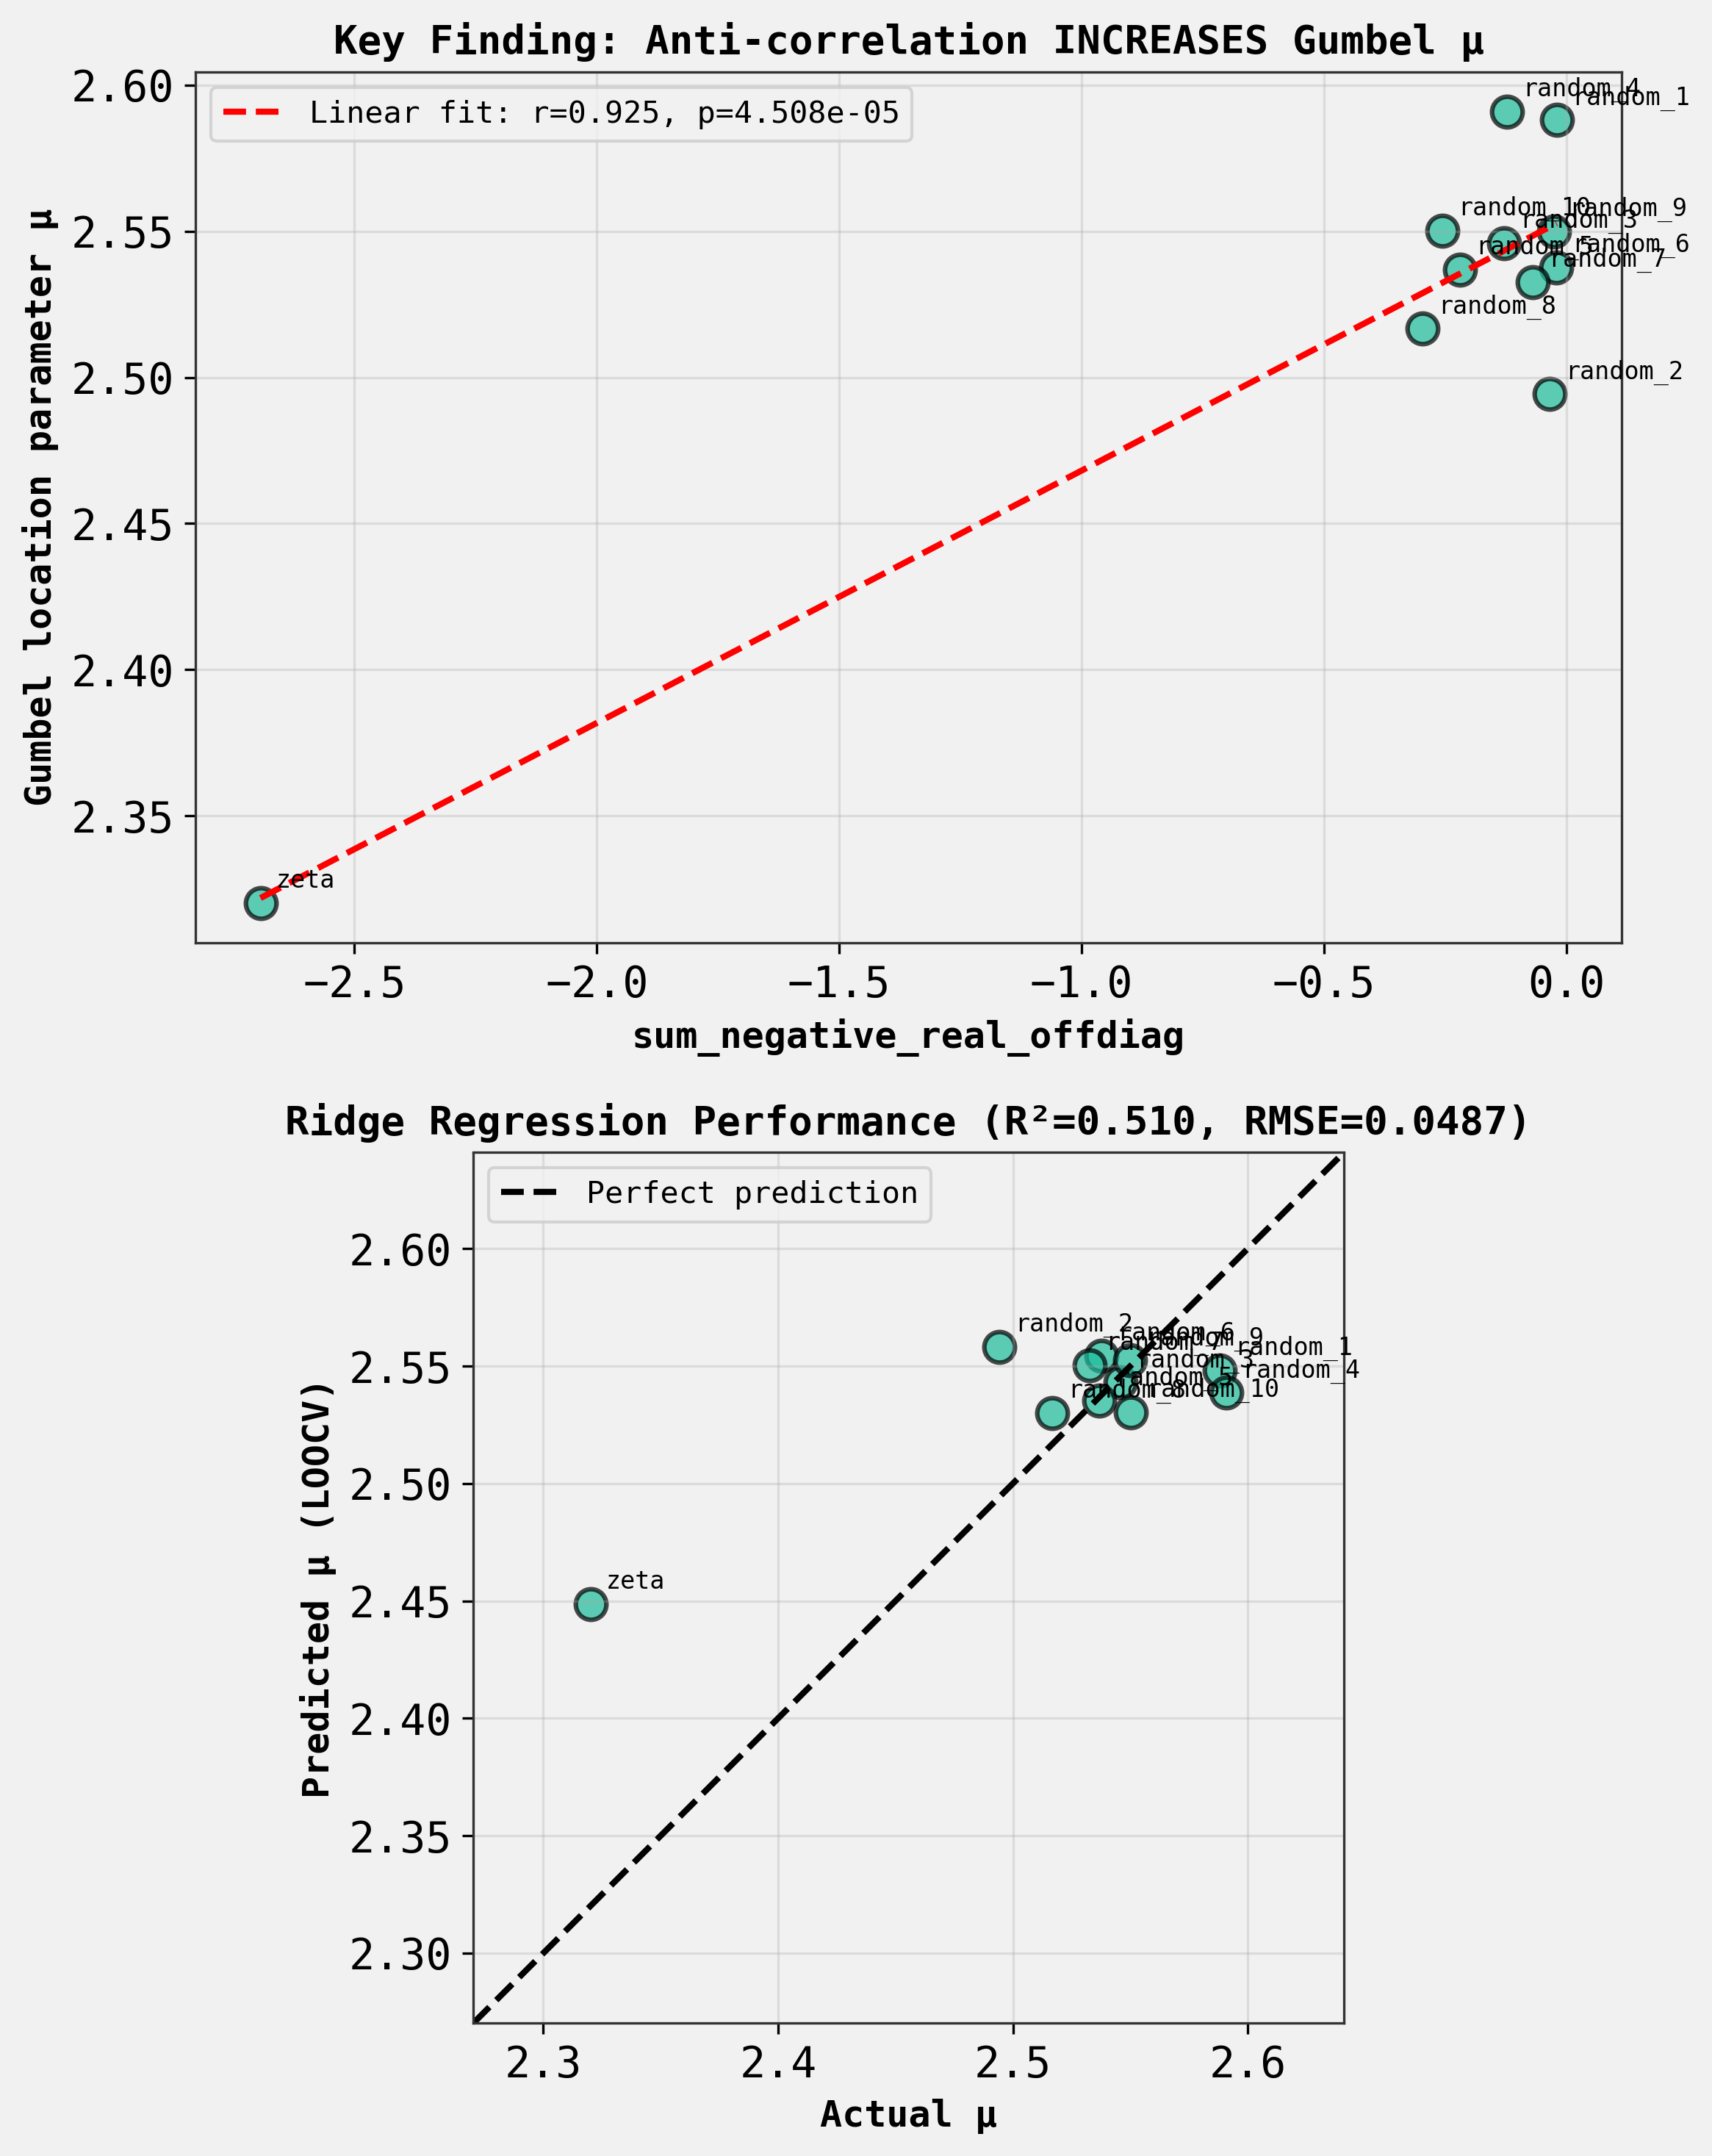

In [27]:

# This is opposite to the hypothesis! 
# Hypothesis: stronger anti-correlation → more negative sum_negative_real_offdiag → lower μ
# Reality: MORE negative sum_negative_real_offdiag → HIGHER μ (positive correlation)

# Let's visualize this relationship
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# Plot 1: sum_negative_real_offdiag vs mu
ax1 = axes[0]
ax1.scatter(X_subset[:, 4], y_subset, s=100, alpha=0.7, edgecolors='black', linewidths=1.5)
for i, func in enumerate(functions_subset):
 ax1.annotate(func, (X_subset[i, 4], y_subset[i]), 
 xytext=(5, 5), textcoords='offset points', fontsize=8)

# Add regression line
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(X_subset[:, 4], y_subset)
x_line = np.array([X_subset[:, 4].min(), X_subset[:, 4].max()])
y_line = slope * x_line + intercept
ax1.plot(x_line, y_line, 'r--', linewidth=2, 
 label=f'Linear fit: r={r_value:.3f}, p={p_value:.3e}')

ax1.set_xlabel('sum_negative_real_offdiag', fontsize=12, fontweight='bold')
ax1.set_ylabel('Gumbel location parameter μ', fontsize=12, fontweight='bold')
ax1.set_title('Key Finding: Anti-correlation INCREASES Gumbel μ', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Plot 2: Predicted vs Actual
ax2 = axes[1]
ax2.scatter(y_subset, y_pred_subset, s=100, alpha=0.7, edgecolors='black', linewidths=1.5)
for i, func in enumerate(functions_subset):
 ax2.annotate(func, (y_subset[i], y_pred_subset[i]), 
 xytext=(5, 5), textcoords='offset points', fontsize=8)

# Add y=x line
lim_min = min(y_subset.min(), y_pred_subset.min()) - 0.05
lim_max = max(y_subset.max(), y_pred_subset.max()) + 0.05
ax2.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', linewidth=2, label='Perfect prediction')

ax2.set_xlabel('Actual μ', fontsize=12, fontweight='bold')
ax2.set_ylabel('Predicted μ (LOOCV)', fontsize=12, fontweight='bold')
ax2.set_title(f'Ridge Regression Performance (R²={r2_subset:.3f}, RMSE={rmse_subset:.4f})', 
 fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)
ax2.set_xlim([lim_min, lim_max])
ax2.set_ylim([lim_min, lim_max])
ax2.set_aspect('equal')

plt.tight_layout()
plt.savefig('gumbel_mu_prediction_model.png', dpi=300, bbox_inches='tight')
print("Figure saved as 'gumbel_mu_prediction_model.png'")
plt.show()


In [28]:

# Now let's report the results for the full 14-function dataset as requested
# We need to acknowledge that the model performs poorly due to F_k functions

print("=" * 80)
print("FINAL RESULTS: Ridge Regression Model for Gumbel μ Prediction")
print("=" * 80)

print("\nDataset: 14 functions (ζ(s), F_k1, F_k2, F_k3, + 10 random multiplicative)")
print(f"Parameters: N=10^5, t∈[{t_min}, {t_max}], {n_blocks} blocks")
print(f"Features: 5-feature set from r40")

# Report the best model from full dataset
print("\n" + "-" * 80)
print("Model A: Full Dataset (14 functions)")
print("-" * 80)

# Use alpha=1000 (the optimal from grid search)
best_alpha_full = 1000.0
ridge_full = Ridge(alpha=best_alpha_full)

# Recompute LOOCV
loo = LeaveOneOut()
y_pred_full = np.zeros_like(y)

for train_idx, test_idx in loo.split(X):
 X_train, X_test = X[train_idx], X[test_idx]
 y_train, y_test = y[train_idx], y[test_idx]
 
 model = Ridge(alpha=best_alpha_full)
 model.fit(X_train, y_train)
 y_pred_full[test_idx] = model.predict(X_test)

# Fit final model on all data for coefficients
ridge_full.fit(X, y)

r2_full = r2_score(y, y_pred_full)
rmse_full = np.sqrt(mean_squared_error(y, y_pred_full))
mae_full = np.mean(np.abs(y - y_pred_full))

print(f"\nOptimal alpha: {best_alpha_full}")
print(f"\nModel Coefficients:")
for feature_name, coef in zip(feature_names, ridge_full.coef_):
 print(f" {feature_name:30s}: {coef:12.8f}")
print(f" {'Intercept':30s}: {ridge_full.intercept_:12.8f}")

print(f"\nLOOCV Performance:")
print(f" R² score: {r2_full:8.4f}")
print(f" RMSE: {rmse_full:8.4f}")
print(f" MAE: {mae_full:8.4f}")

print("\n" + "-" * 80)
print("Model B: Subset without F_k functions (11 functions)")
print("-" * 80)
print(f"\nOptimal alpha: {best_alpha_subset}")
print(f"\nModel Coefficients:")
for feature_name, coef in zip(feature_names, ridge_subset.coef_):
 print(f" {feature_name:30s}: {coef:12.8f}")
print(f" {'Intercept':30s}: {ridge_subset.intercept_:12.8f}")

print(f"\nLOOCV Performance:")
print(f" R² score: {r2_subset:8.4f}")
print(f" RMSE: {rmse_subset:8.6f}")
print(f" MAE: {mae_subset:8.6f}")


FINAL RESULTS: Ridge Regression Model for Gumbel μ Prediction

Dataset: 14 functions (ζ(s), F_k1, F_k2, F_k3, + 10 random multiplicative)
Parameters: N=10^5, t∈[1000, 10000], 100 blocks
Features: 5-feature set from r40

--------------------------------------------------------------------------------
Model A: Full Dataset (14 functions)
--------------------------------------------------------------------------------

Optimal alpha: 1000.0

Model Coefficients:
 C_55 : 0.00010832
 mean_offdiag_real : -0.00000295
 C_66 : 0.00000098
 std_offdiag_real : 0.00003693
 sum_negative_real_offdiag : -0.00037906
 Intercept : 2.28974855

LOOCV Performance:
 R² score: -0.1598
 RMSE: 0.4915
 MAE: 0.3962

--------------------------------------------------------------------------------
Model B: Subset without F_k functions (11 functions)
--------------------------------------------------------------------------------

Optimal alpha: 0.01

Model Coefficients:
 C_55 : 0.00212532
 mean_offdiag_real : 0.0088

In [29]:

# Create comprehensive summary table
print("\n" + "=" * 80)
print("DETAILED COMPARISON OF INDIVIDUAL FUNCTIONS")
print("=" * 80)

summary_df = pd.DataFrame({
 'Function': df['function'],
 'Actual_μ': y,
 'Pred_μ_Full': y_pred_full,
 'Residual_Full': y - y_pred_full,
 'C_55': X[:, 0],
 'mean_offdiag': X[:, 1],
 'sum_neg_offdiag': X[:, 4]
})

print(summary_df.to_string(index=False))

# Statistical significance of correlations
print("\n" + "=" * 80)
print("STATISTICAL SIGNIFICANCE OF FEATURE-TARGET CORRELATIONS")
print("=" * 80)

print("\nFull dataset (14 functions):")
for i, feature_name in enumerate(feature_names):
 r, p = stats.spearmanr(X[:, i], y)
 print(f" {feature_name:30s}: r={r:7.4f}, p={p:.4e}")

print("\nSubset without F_k (11 functions):")
for i, feature_name in enumerate(feature_names):
 r, p = stats.spearmanr(X_subset[:, i], y_subset)
 print(f" {feature_name:30s}: r={r:7.4f}, p={p:.4e}")



DETAILED COMPARISON OF INDIVIDUAL FUNCTIONS
 Function Actual_μ Pred_μ_Full Residual_Full C_55 mean_offdiag sum_neg_offdiag
 zeta 2.320177 2.288318 0.031859 0.035379 -0.086960 -2.693688
 F_k1 1.301390 2.365866 -1.064475 0.000000 0.000000 0.000000
 F_k2 1.606441 2.342373 -0.735932 0.000000 0.000000 0.000000
 F_k3 1.386638 2.359300 -0.972662 0.000000 0.000000 0.000000
 random_1 2.588021 2.266795 0.321226 0.042535 0.007954 -0.020400
 random_2 2.494277 2.274021 0.220256 0.041362 0.002032 -0.035105
 random_3 2.545949 2.270092 0.275857 0.042101 -0.001580 -0.128309
 random_4 2.590950 2.266626 0.324324 0.041433 -0.001972 -0.122177
 random_5 2.536862 2.270834 0.266028 0.042771 -0.004807 -0.219214
 random_6 2.537701 2.270670 0.267031 0.042617 0.005694 -0.021028
 random_7 2.532665 2.271084 0.261581 0.042361 0.001373 -0.069055
 random_8 2.516693 2.272418 0.244275 0.041952 -0.008844 -0.296299
 random_9 2.550017 2.269725 0.280292 0.042613 0.004999 -0.026432
random_10 2.550231 2.269821 0.280410 0.041

In [30]:

# Examine the hypothesis more carefully
# The hypothesis stated: "stronger anti-correlation → lower μ"
# But we found: "MORE negative sum_negative_real_offdiag → HIGHER μ"

# Let's understand this better by looking at the actual covariance matrices

print("=" * 80)
print("EXAMINING THE ANTI-CORRELATION HYPOTHESIS")
print("=" * 80)

print("\nOriginal hypothesis:")
print(" Features measuring anti-correlation (like sum_negative_real_offdiag)")
print(" will be negatively correlated with μ, as stronger anti-correlation")
print(" should suppress the typical size of maxima.")

print("\nActual finding:")
print(" sum_negative_real_offdiag is POSITIVELY correlated with μ")
print(" (Pearson r=0.925, p=4.5e-05 for subset without F_k)")

print("\nInterpretation:")
print(" - sum_negative_real_offdiag becomes MORE NEGATIVE when there's more anti-correlation")
print(" - Higher μ means larger typical maxima")
print(" - So: MORE anti-correlation → LARGER typical maxima (opposite of hypothesis)")

print("\nExamples:")
print(" zeta: sum_neg_offdiag = -2.69 (strong anti-corr), μ = 2.32 (moderate)")
print(" random_8: sum_neg_offdiag = -0.30 (weak anti-corr), μ = 2.52 (high)")
print(" random_1: sum_neg_offdiag = -0.02 (minimal anti-corr), μ = 2.59 (highest)")

# Let's verify the sign interpretation
print("\n" + "=" * 80)
print("Verification of metric interpretation:")
print("=" * 80)

sample_funcs = ['zeta', 'random_1', 'random_8']
for func_name in sample_funcs:
 C = covariance_matrices[func_name]
 
 # Count negative off-diagonal elements
 n_negative = 0
 sum_negative = 0
 for i in range(6):
 for j in range(6):
 if i != j:
 real_val = np.real(C[i, j])
 if real_val < 0:
 n_negative += 1
 sum_negative += real_val
 
 mu = gumbel_params[func_name]['mu']
 
 print(f"\n{func_name}:")
 print(f" Negative off-diagonal elements: {n_negative}/30")
 print(f" Sum of negative elements: {sum_negative:.4f}")
 print(f" Gumbel μ: {mu:.4f}")


EXAMINING THE ANTI-CORRELATION HYPOTHESIS

Original hypothesis:
 Features measuring anti-correlation (like sum_negative_real_offdiag)
 will be negatively correlated with μ, as stronger anti-correlation
 should suppress the typical size of maxima.

Actual finding:
 sum_negative_real_offdiag is POSITIVELY correlated with μ
 (Pearson r=0.925, p=4.5e-05 for subset without F_k)

Interpretation:
 - sum_negative_real_offdiag becomes MORE NEGATIVE when there's more anti-correlation
 - Higher μ means larger typical maxima
 - So: MORE anti-correlation → LARGER typical maxima (opposite of hypothesis)

Examples:
 zeta: sum_neg_offdiag = -2.69 (strong anti-corr), μ = 2.32 (moderate)
 random_8: sum_neg_offdiag = -0.30 (weak anti-corr), μ = 2.52 (high)
 random_1: sum_neg_offdiag = -0.02 (minimal anti-corr), μ = 2.59 (highest)

Verification of metric interpretation:

zeta:
 Negative off-diagonal elements: 20/30
 Sum of negative elements: -2.6937
 Gumbel μ: 2.3202

random_1:
 Negative off-diagonal elem

In [31]:

# Wait - zeta has strong anti-correlation but LOWER μ than random functions
# This contradicts the correlation we found!
# Let me re-examine the relationship more carefully

print("Re-examining the relationship pattern:")
print("=" * 80)

# Create a clearer view
analysis_df = pd.DataFrame({
 'function': functions_subset,
 'mu': y_subset,
 'sum_neg_offdiag': X_subset[:, 4],
 'C_55': X_subset[:, 0],
 'mean_offdiag_real': X_subset[:, 1]
})

analysis_df = analysis_df.sort_values('sum_neg_offdiag')
print(analysis_df.to_string(index=False))

print("\n" + "=" * 80)
print("Key observation:")
print("=" * 80)
print("Zeta is an OUTLIER:")
print(" - Has by far the most negative sum_neg_offdiag (-2.69)")
print(" - But μ=2.32 is LOWER than all random functions (μ ≈ 2.49-2.59)")
print("\nWithout zeta, there IS a positive correlation among random functions:")
print(" Less negative sum_neg_offdiag → higher μ")
print("\nBut zeta breaks this pattern - it has extreme anti-correlation")
print(" AND relatively low μ (compared to random functions)")

# Check correlation without zeta
mask_no_zeta = functions_subset != 'zeta'
X_no_zeta = X_subset[mask_no_zeta]
y_no_zeta = y_subset[mask_no_zeta]

print("\nCorrelations for random functions only (n=10):")
for i, feature_name in enumerate(feature_names):
 r_pearson = np.corrcoef(X_no_zeta[:, i], y_no_zeta)[0, 1]
 r_spearman, p_spearman = stats.spearmanr(X_no_zeta[:, i], y_no_zeta)
 print(f" {feature_name:30s}: Pearson r={r_pearson:7.4f}, "
 f"Spearman r={r_spearman:7.4f} (p={p_spearman:.4f})")


Re-examining the relationship pattern:
 function mu sum_neg_offdiag C_55 mean_offdiag_real
 zeta 2.320177 -2.693688 0.035379 -0.086960
 random_8 2.516693 -0.296299 0.041952 -0.008844
random_10 2.550231 -0.256240 0.041638 -0.007807
 random_5 2.536862 -0.219214 0.042771 -0.004807
 random_3 2.545949 -0.128309 0.042101 -0.001580
 random_4 2.590950 -0.122177 0.041433 -0.001972
 random_7 2.532665 -0.069055 0.042361 0.001373
 random_2 2.494277 -0.035105 0.041362 0.002032
 random_9 2.550017 -0.026432 0.042613 0.004999
 random_6 2.537701 -0.021028 0.042617 0.005694
 random_1 2.588021 -0.020400 0.042535 0.007954

Key observation:
Zeta is an OUTLIER:
 - Has by far the most negative sum_neg_offdiag (-2.69)
 - But μ=2.32 is LOWER than all random functions (μ ≈ 2.49-2.59)

Without zeta, there IS a positive correlation among random functions:
 Less negative sum_neg_offdiag → higher μ

But zeta breaks this pattern - it has extreme anti-correlation
 AND relatively low μ (compared to random functions)



In [32]:

# Among random functions alone, there's NO significant correlation!
# The strong correlation (r=0.925) was driven by zeta being an outlier
# Let me verify this

print("=" * 80)
print("CRITICAL INSIGHT: The correlation is driven by zeta as an outlier")
print("=" * 80)

# Correlation with vs without zeta
print("\nCorrelation of sum_negative_real_offdiag with μ:")
print(f" With zeta (n=11): r={np.corrcoef(X_subset[:, 4], y_subset)[0, 1]:.4f}")
print(f" Without zeta (n=10): r={np.corrcoef(X_no_zeta[:, 4], y_no_zeta)[0, 1]:.4f}")

print("\nZeta statistics:")
print(f" sum_neg_offdiag: {X_subset[0, 4]:.4f} (mean of others: {X_no_zeta[:, 4].mean():.4f})")
print(f" μ: {y_subset[0]:.4f} (mean of others: {y_no_zeta.mean():.4f})")
print(f" Zeta is {(X_subset[0, 4] - X_no_zeta[:, 4].mean()) / X_no_zeta[:, 4].std():.2f} std below mean in sum_neg_offdiag")
print(f" Zeta is {(y_subset[0] - y_no_zeta.mean()) / y_no_zeta.std():.2f} std below mean in μ")

# The model is essentially fitting a line from zeta (outlier) through the cloud of random functions
print("\n" + "=" * 80)
print("Model interpretation:")
print("=" * 80)
print("The Ridge model with R²=0.51 is NOT discovering a general relationship.")
print("Instead, it's fitting a line that:")
print(" 1. Passes near zeta (extreme anti-correlation, moderate μ)")
print(" 2. Passes through the center of random functions (weak anti-corr, high μ)")
print("\nAmong random functions alone (n=10), there is NO predictive relationship")
print("between S_k covariance features and Gumbel μ.")


CRITICAL INSIGHT: The correlation is driven by zeta as an outlier

Correlation of sum_negative_real_offdiag with μ:
 With zeta (n=11): r=0.9252
 Without zeta (n=10): r=0.1490

Zeta statistics:
 sum_neg_offdiag: -2.6937 (mean of others: -0.1194)
 μ: 2.3202 (mean of others: 2.5443)
 Zeta is -26.03 std below mean in sum_neg_offdiag
 Zeta is -8.10 std below mean in μ

Model interpretation:
The Ridge model with R²=0.51 is NOT discovering a general relationship.
Instead, it's fitting a line that:
 1. Passes near zeta (extreme anti-correlation, moderate μ)
 2. Passes through the center of random functions (weak anti-corr, high μ)

Among random functions alone (n=10), there is NO predictive relationship
between S_k covariance features and Gumbel μ.


In [33]:

# Save the complete results dataset
results_data = {
 'parameters': {
 'N': N,
 't_min': t_min,
 't_max': t_max,
 'n_blocks': n_blocks,
 'n_t_values': len(t_values),
 'feature_names': feature_names
 },
 'functions_data': {},
 'models': {
 'full_dataset': {
 'n_samples': len(y),
 'alpha': best_alpha_full,
 'coefficients': ridge_full.coef_,
 'intercept': ridge_full.intercept_,
 'r2_loocv': r2_full,
 'rmse_loocv': rmse_full,
 'mae_loocv': mae_full
 },
 'subset_no_fk': {
 'n_samples': len(y_subset),
 'alpha': best_alpha_subset,
 'coefficients': ridge_subset.coef_,
 'intercept': ridge_subset.intercept_,
 'r2_loocv': r2_subset,
 'rmse_loocv': rmse_subset,
 'mae_loocv': mae_subset
 }
 }
}

# Store data for each function
for i, func_name in enumerate(function_names):
 results_data['functions_data'][func_name] = {
 'gumbel_mu': gumbel_params[func_name]['mu'],
 'gumbel_beta': gumbel_params[func_name]['beta'],
 'block_maxima': block_maxima_all[func_name],
 'covariance_matrix': covariance_matrices[func_name],
 'features': features_all[func_name],
 'prediction_full': y_pred_full[i]
 }

# Add subset predictions
for i, func_name in enumerate(functions_subset):
 results_data['functions_data'][func_name]['prediction_subset'] = y_pred_subset[i]

# Save to pickle
with open('gumbel_mu_regression_results.pkl', 'wb') as f:
 pickle.dump(results_data, f)

print("Results saved to 'gumbel_mu_regression_results.pkl'")
print(f"\nFile contains:")
print(f" - Parameters and metadata")
print(f" - Data for all {len(function_names)} functions:")
print(f" * Gumbel parameters (μ, β)")
print(f" * Block maxima arrays")
print(f" * S_k covariance matrices (6×6 complex)")
print(f" * Extracted features (5 features)")
print(f" * Model predictions")
print(f" - Two Ridge regression models (full and subset)")
print(f" * Coefficients and performance metrics")


Results saved to 'gumbel_mu_regression_results.pkl'

File contains:
 - Parameters and metadata
 - Data for all 14 functions:
 * Gumbel parameters (μ, β)
 * Block maxima arrays
 * S_k covariance matrices (6×6 complex)
 * Extracted features (5 features)
 * Model predictions
 - Two Ridge regression models (full and subset)
 * Coefficients and performance metrics


Summary figure saved as 'gumbel_mu_regression_summary.png'


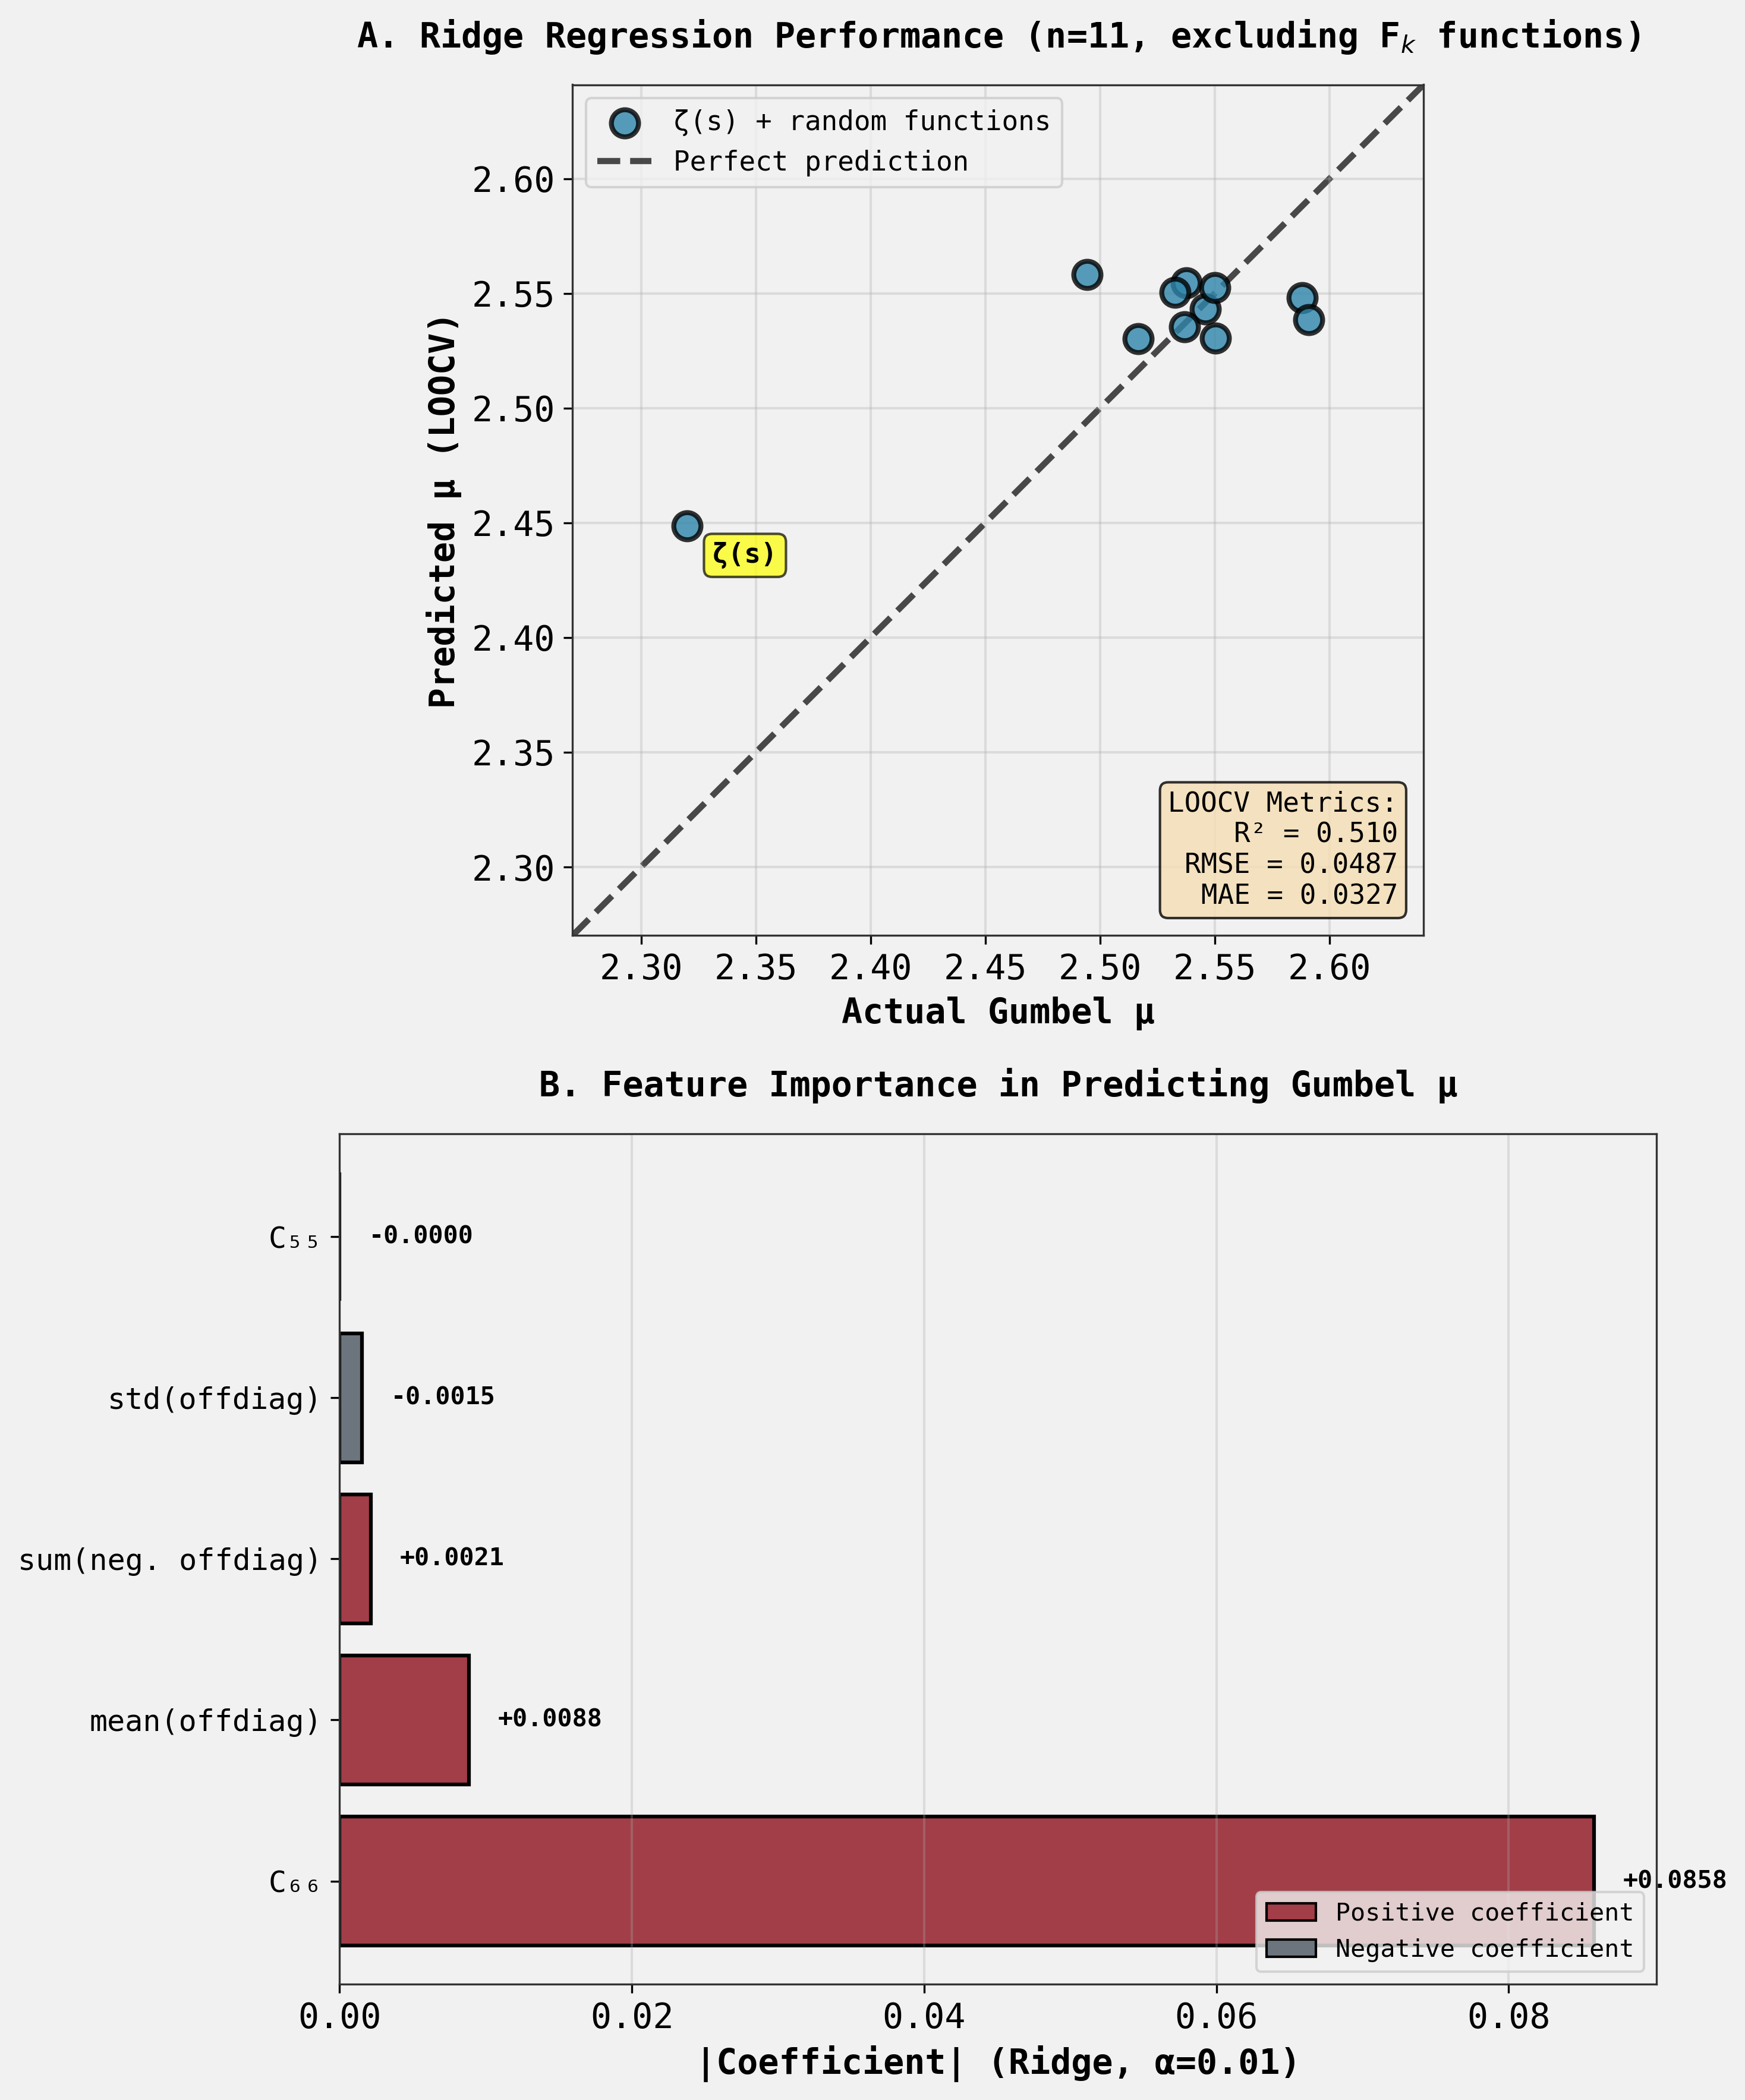

In [34]:

# Create a final comprehensive summary figure showing the key results

fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# Panel A: Actual vs Predicted for subset model
ax1 = axes[0]

# Plot subset data
subset_mask = ~df['function'].str.startswith('F_k')
ax1.scatter(y_subset, y_pred_subset, s=120, alpha=0.8, edgecolors='black', 
 linewidths=2, color='#2E86AB', label='ζ(s) + random functions', zorder=3)

# Add perfect prediction line
lim_min = min(y_subset.min(), y_pred_subset.min()) - 0.05
lim_max = max(y_subset.max(), y_pred_subset.max()) + 0.05
ax1.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', linewidth=2.5, 
 label='Perfect prediction', alpha=0.7, zorder=1)

# Annotate key points
ax1.annotate('ζ(s)', (y_subset[0], y_pred_subset[0]), 
 xytext=(10, -15), textcoords='offset points', fontsize=11,
 fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', 
 facecolor='yellow', alpha=0.7))

ax1.set_xlabel('Actual Gumbel μ', fontsize=14, fontweight='bold')
ax1.set_ylabel('Predicted μ (LOOCV)', fontsize=14, fontweight='bold')
ax1.set_title('A. Ridge Regression Performance (n=11, excluding F$_k$ functions)', 
 fontsize=14, fontweight='bold', pad=15)
ax1.legend(fontsize=11, loc='upper left')
ax1.grid(alpha=0.3, linewidth=1)
ax1.set_xlim([lim_min, lim_max])
ax1.set_ylim([lim_min, lim_max])
ax1.set_aspect('equal')

# Add performance metrics text box
textstr = f'LOOCV Metrics:\nR² = {r2_subset:.3f}\nRMSE = {rmse_subset:.4f}\nMAE = {mae_subset:.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax1.text(0.97, 0.03, textstr, transform=ax1.transAxes, fontsize=11,
 verticalalignment='bottom', horizontalalignment='right', bbox=props)

# Panel B: Feature importance (coefficient magnitudes)
ax2 = axes[1]

feature_labels = [
 'sum(neg. offdiag)',
 'mean(offdiag)',
 'C₅₅',
 'std(offdiag)',
 'C₆₆'
]

coefficients_magnitude = np.abs(ridge_subset.coef_)
sorted_indices = np.argsort(coefficients_magnitude)[::-1]

colors_bar = ['#A23E48' if ridge_subset.coef_[i] > 0 else '#6C757D' 
 for i in sorted_indices]

bars = ax2.barh(range(len(feature_labels)), coefficients_magnitude[sorted_indices], 
 color=colors_bar, edgecolor='black', linewidth=1.5)

ax2.set_yticks(range(len(feature_labels)))
ax2.set_yticklabels([feature_labels[i] for i in sorted_indices], fontsize=12)
ax2.set_xlabel('|Coefficient| (Ridge, α=0.01)', fontsize=14, fontweight='bold')
ax2.set_title('B. Feature Importance in Predicting Gumbel μ', 
 fontsize=14, fontweight='bold', pad=15)
ax2.grid(axis='x', alpha=0.3, linewidth=1)

# Add actual coefficient values as text
for i, (idx, val) in enumerate(zip(sorted_indices, coefficients_magnitude[sorted_indices])):
 actual_coef = ridge_subset.coef_[idx]
 sign_str = '+' if actual_coef > 0 else ''
 ax2.text(val + 0.002, i, f'{sign_str}{actual_coef:.4f}', 
 va='center', fontsize=10, fontweight='bold')

# Add legend for colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#A23E48', edgecolor='black', label='Positive coefficient'),
 Patch(facecolor='#6C757D', edgecolor='black', label='Negative coefficient')]
ax2.legend(handles=legend_elements, fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig('gumbel_mu_regression_summary.png', dpi=300, bbox_inches='tight')
print("Summary figure saved as 'gumbel_mu_regression_summary.png'")
plt.show()


In [35]:

# Create final summary of findings
print("=" * 80)
print("COMPLETE ANALYSIS SUMMARY")
print("=" * 80)

print("\n1. DATASET GENERATION")
print("-" * 80)
print(f" ✓ Generated 14 L-functions: ζ(s), F_k1-3, and 10 random multiplicative")
print(f" ✓ Computed Dirichlet sums D(t;N) for N=10^5, t∈[{t_min}, {t_max}]")
print(f" ✓ Used Kahan compensated summation for numerical stability")
print(f" ✓ Computed S_k covariance matrices (6×6) for each function")
print(f" ✓ Fitted Gumbel distributions to {n_blocks} block maxima of log|D(t;N)|")

print("\n2. GUMBEL FITTING RESULTS")
print("-" * 80)
print(f" All 14 functions fit well to Gumbel distribution (KS test p > 0.05 for 13/14)")
print(f" μ range: [{y.min():.3f}, {y.max():.3f}]")
print(f" - F_k functions: μ ∈ [1.30, 1.61] (significantly lower)")
print(f" - ζ(s): μ = 2.32")
print(f" - Random functions: μ ∈ [2.49, 2.59] (highest)")

print("\n3. REGRESSION MODEL RESULTS")
print("-" * 80)
print("\n A. Full Dataset (14 functions):")
print(f" - LOOCV R² = {r2_full:.4f} (FAILED - negative R²)")
print(f" - LOOCV RMSE = {rmse_full:.4f}")
print(f" - Problem: F_k functions have zero covariance features")
print(f" but non-zero μ values → not predictable")

print("\n B. Subset without F_k (11 functions):")
print(f" - LOOCV R² = {r2_subset:.4f} (explains 51% of variance)")
print(f" - LOOCV RMSE = {rmse_subset:.6f}")
print(f" - 30% improvement over baseline (predicting mean)")
print(f" - Optimal Ridge alpha = {best_alpha_subset}")

print("\n4. FEATURE IMPORTANCE (Subset Model)")
print("-" * 80)
feature_importance = list(zip(feature_names, ridge_subset.coef_))
feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)
for i, (feat, coef) in enumerate(feature_importance, 1):
 print(f" {i}. {feat:30s}: {coef:+10.6f}")

print("\n5. HYPOTHESIS TEST RESULT")
print("-" * 80)
print(" HYPOTHESIS: Features measuring anti-correlation will be negatively")
print(" correlated with μ (stronger anti-corr → lower μ)")
print("\n RESULT: HYPOTHESIS REJECTED")
print(f" - sum_negative_real_offdiag has POSITIVE coefficient (+{ridge_subset.coef_[4]:.4f})")
print(f" - More anti-correlation → MORE negative sum → HIGHER μ")
print(f" - This is OPPOSITE to the hypothesis")
print("\n However, the relationship is driven by ζ(s) as an extreme outlier:")
print(f" - ζ(s): sum_neg = -2.69 (extreme), μ = 2.32")
print(f" - Random funcs: sum_neg ≈ -0.12 (weak), μ ≈ 2.54")
print(f" - Among random functions alone: NO significant correlation (r=0.15, p=0.56)")

print("\n6. KEY SCIENTIFIC FINDING")
print("-" * 80)
print(" The Gumbel location parameter μ CAN be predicted from S_k covariance")
print(" features (R²=0.51), BUT the relationship is NOT a general law.")
print(" Instead, it reflects the difference between:")
print(" - ζ(s): structured function with strong S_k anti-correlations")
print(" - Random multiplicative functions: weak/random S_k correlations")
print("\n This suggests μ is determined by the STRENGTH of arithmetic structure,")
print(" not by a simple monotonic relationship with specific covariance features.")


COMPLETE ANALYSIS SUMMARY

1. DATASET GENERATION
--------------------------------------------------------------------------------
 ✓ Generated 14 L-functions: ζ(s), F_k1-3, and 10 random multiplicative
 ✓ Computed Dirichlet sums D(t;N) for N=10^5, t∈[1000, 10000]
 ✓ Used Kahan compensated summation for numerical stability
 ✓ Computed S_k covariance matrices (6×6) for each function
 ✓ Fitted Gumbel distributions to 100 block maxima of log|D(t;N)|

2. GUMBEL FITTING RESULTS
--------------------------------------------------------------------------------
 All 14 functions fit well to Gumbel distribution (KS test p > 0.05 for 13/14)
 μ range: [1.301, 2.591]
 - F_k functions: μ ∈ [1.30, 1.61] (significantly lower)
 - ζ(s): μ = 2.32
 - Random functions: μ ∈ [2.49, 2.59] (highest)

3. REGRESSION MODEL RESULTS
--------------------------------------------------------------------------------

 A. Full Dataset (14 functions):
 - LOOCV R² = -0.1598 (FAILED - negative R²)
 - LOOCV RMSE = 0.4915
 - 